# Fase 2 - Análisis inferencial

**Pregunta de investigación:** ¿De qué manera el nivel educativo impacta en los ingresos laborales de la Población Económicamente Activa (PEA) en Paraguay durante el año 2025?

Este notebook contiene la Fase 2, en dos partes:

## Parte A - Cambios realizados con respecto a la Fase 1

**Reconstrucción del dataset limpio.** Se parte del archivo **original** de la EPHC 2025 (`REG02_EPHC_ANUAL_2025.csv`, 213 columnas, 55.934 personas) y se repiten los pasos de la Fase 1 (selección de variables y limpieza), pero corrigiendo algunos errores detectados al revisar los resultados de la Fase 1:

**1. Redefinición de la Población de Análisis (Filtro de Edad y Ocupación)**

En la propuesta anterior, la población de análisis estaba conformada por personas de 15 años o más que se encontraban ocupadas (PEAA = 1). Actualmente se estableció un límite inferior de 18 años y superior de 60 años, conservando únicamente las personas con edades comprendidas entre 18 y 60 años inclusive.

Este cambio reduce la población analizada a 24.379 registros. La decisión busca trabajar con una población adulta dentro de un intervalo de edad previamente delimitado y mantener mayor homogeneidad en la comparación de las variables de educación e ingresos, eliminando además distorsiones asociadas al retiro, jubilaciones o pensiones de adultos mayores.

Este cambio debe ser tenido en cuenta en la interpretación de los resultados inferenciales, ya que modifica la población sobre la cual se realizarán las estimaciones y pruebas estadísticas.

**2. Cambio del identificador único para cada registro**

Se agregó la variable ID_PERSONA, generada de forma secuencial para cada observación del conjunto limpio y reemplazando al ID compuesto CLAVE_PERSONA usado en la fase 1.

Este identificador permite realizar una mejor trazabilidad de los registros y permite identificar cada observación de forma sencilla durante el desarrollo del análisis.

**3. Error de formato (coma decimal):** `e01aimde`, `e01bimde` y `e01cimde` (ingreso habitual) vienen en el archivo original con coma como separador decimal (ej. `4917667,813`). Al convertir directamente a numérico sin reemplazar la coma por punto, esos valores se pierden como `NaN`; esto hacía que `e01aimde` tuviera solo ~28% de datos válidos en la Fase 1, cuando en realidad la cobertura real es casi completa para los ocupados.

**4. Error en `estrato_educativo`:** el corte `ED0504 >= 1000` usado en la Fase 1 para "terciaria/universitaria" incluía por error los programas de educación media alternativa, de jóvenes y adultos, y de alfabetización (códigos 1001-1900), que el diccionario de la EPHC no clasifica como terciaria.
  - **Códigos de "no disponible" sin recodificar:** `ED0504` en {8888, 9999} e `informalidad == 9` quedaban como si fueran categorías válidas.

**5. Actualización de los controles de calidad y del archivo final**

Se incorporaron nuevos controles para verificar la cantidad final de registros, la cantidad de columnas, **la ausencia de duplicados en ID_PERSONA** y la **inexistencia de ingresos negativos**. Finalmente, el conjunto limpio se volvió a guardar incluyendo estos cambios.

Estas modificaciones permiten asegurar que el dataset utilizado en la Etapa 2 sea reproducible, trazable y esté respaldado por controles de calidad.

## **Parte B — Análisis inferencial (Fase 2 propiamente dicha).**

Se formulan 4 hipótesis y, para cada una, se aplican 3 pruebas combinando. según el caso: Z, t de Student, ANOVA de un factor, Tukey HSD y ANOVA factorial para decidir si se rechaza o no cada hipótesis nula. Se agregan además los controles de calidad: supuestos (normalidad, homogeneidad de varianzas), el tamaño del efecto, la corrección de Bonferroni para comparaciones múltiples y un intervalo de confianza bootstrap comparado con el clásico según consideramos necesario para cada hipótesis.

## Configuración inicial

1. **Importar librerías a usar**
2. **Definir variables globales:** usaremos un nivel de confianza estándar del 95% (indicado con el valor `ALPHA = 0.05`) para decidir si los hallazgos son estadísticamente seguros o podrían deberse al azar.
3. **Para reproducibilidad:** se activa un generador de números aleatorios con una "semilla" fija (`42`) para *Bootstrap*.
4. **Lectura de resultados:** Configura el sistema para que todos los montos de dinero se muestren con separadores de miles y tres decimales, haciendo que las tablas finales sean más fáciles de leer.

In [32]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy.stats import norm, t as t_dist

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

ALPHA = 0.05
rng = np.random.default_rng(42)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Parte A — Reconstrucción del dataset limpio

Se repiten, sobre el archivo **original**, los pasos de selección (Fase 1, Etapa 2) y limpieza (Fase 1, Etapa 3), incorporando las correcciones descritas arriba.

In [33]:
import requests
from pathlib import Path

# URL del archivo a descargar
url = "https://www.ine.gov.py/microdatos/register/EPHC-ANUAL/EPHC_2025_ANUAL/REG02_EPHC_ANUAL_2025.csv"

# Nombre del archivo y ruta de destino (carpeta raíz)
file_name = "REG02_EPHC_ANUAL_2025.csv"
file_path = Path(file_name)

print(f"Descargando {file_name} en la carpeta raíz...")
# PARA DESCARGAR EL DATASET DESDE ESTA CELDA, QUITAR ESTE BLOQUE DE COMENTARIOS
# response = requests.get(url, stream=True)
# response.raise_for_status()

# with open(file_path, 'wb') as f:
#     for chunk in response.iter_content(chunk_size=8192):
#         f.write(chunk)

print(f"Descarga completada: '{file_name}' guardado correctamente.")

Descargando REG02_EPHC_ANUAL_2025.csv en la carpeta raíz...
Descarga completada: 'REG02_EPHC_ANUAL_2025.csv' guardado correctamente.


In [34]:
RUTA_ORIGINAL = file_path
# El archivo original de la EPHC usa ';' como separador, codificación UTF-8 con BOM,
# y los valores en blanco se registran como un espacio " " en vez de una celda vacía;
# por eso se carga todo como texto (dtype=str) y se decodifica a mano en los pasos siguientes.
df_raw = pd.read_csv(RUTA_ORIGINAL, sep=";", encoding="utf-8-sig", dtype=str, low_memory=False)

print(f"Archivo: {RUTA_ORIGINAL.name}")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.head()

Archivo: REG02_EPHC_ANUAL_2025.csv
Filas: 8,699 | Columnas: 213


,UPM,NVIVI,NHOGA,AÑO,DPTO,AREA,L02,P02,P03,P04,...,ingrevasode,ingrealmuerzode,ipcm,pobrezai,pobnopoi,quintili,decili,quintiai,decilai,informalidad
0,14,13,1,2025,0,1,1,65,1,1,...,0,0,"9470322,87750703",3,0,5,10,5,10,
1,14,13,1,2025,0,1,2,69,2,1,...,0,0,"9470322,87750703",3,0,5,10,5,10,2
2,14,15,1,2025,0,1,1,78,1,1,...,0,0,2080500,3,0,4,7,3,6,
3,14,15,1,2025,0,1,2,78,2,1,...,0,0,2080500,3,0,4,7,3,6,
4,14,16,1,2025,0,1,1,40,1,1,...,0,0,"3535490,19607843",3,0,5,9,5,9,2


In [35]:
def clave(nombre):
    """Normaliza un nombre de columna: sin tildes, en minúsculas y sin espacios extra.
    Se usa para encontrar columnas del archivo original tolerando diferencias de
    mayúsculas/minúsculas (ej. 'Factor' vs 'FACTOR')."""
    s = unicodedata.normalize("NFKD", str(nombre).strip())
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    return re.sub(r"\s+", "", s).casefold()

_claves_df_raw = {clave(c): c for c in df_raw.columns}

def real(v):
    """Devuelve el nombre real de la columna en df_raw, tolerando mayúsculas/tildes."""
    return _claves_df_raw.get(clave(v))

### A.1 Selección de variables (Fase 1, Etapa 2)

Se reutilizan todas las 56 variables que se decidió conservar en la Fase 1.

In [36]:
CONSERVAR = {
    "Identificación y diseño muestral": ["UPM", "NVIVI", "NHOGA", "L02", "FACTOR"],
    "Ubicación y sociodemográficas": ["DPTO", "AREA", "P02", "P04", "P06", "P08A"],
    "Educación": ["añoest", "ED0504", "ED06C", "ED08"],
    "Actividad y perfil ocupacional": ["PEAA", "PEAD", "CATE_PEA", "OCUP_PEA", "RAMA_PEA", "TAMA_PEA", "informalidad"],
    "Ingresos laborales": ["E01A", "E01B", "E01C", "e01aimde", "e01bimde", "e01cimde"],
    "Jornada laboral y pluriempleo": ["HORAB", "HORABC", "HORABCO", "B06", "B07A", "B07M", "B07S",
                                      "B09A", "B09M", "B09S", "B31"],
    "Calidad del empleo": ["B10", "B11", "B12A", "B13", "B14", "B15", "B26", "B28", "B29", "B30",
                            "S01A", "S01B", "S02"],
    "Subocupación": ["D01", "D02", "D03", "D04"],
}

VARIABLES_CONSERVAR = [v for grupo in CONSERVAR.values() for v in grupo]
print(f"Variables a conservar (idénticas a las de la Fase 1, Etapa 2 -- sin B12): {len(VARIABLES_CONSERVAR)}")

columnas_reales, no_encontradas = [], []
for v in VARIABLES_CONSERVAR:
    c = real(v)
    if c is None:
        no_encontradas.append(v)
    else:
        columnas_reales.append(c)

if no_encontradas:
    raise KeyError(f"No se encontraron en el archivo original: {no_encontradas}")

df1 = df_raw[columnas_reales].copy()
# Se renombra a los nombres de VARIABLES_CONSERVAR, para que el resto del
# notebook no dependa de diferencias de mayúsculas/minúsculas del archivo original.
df1 = df1.rename(columns=dict(zip(columnas_reales, VARIABLES_CONSERVAR)))

print(f"Dataset seleccionado: {df1.shape[0]:,} filas x {df1.shape[1]} columnas")

Variables a conservar (idénticas a las de la Fase 1, Etapa 2 -- sin B12): 56
Dataset seleccionado: 8,699 filas x 56 columnas


### A.2 Limpieza: valores en blanco y formato de coma decimal

**Corrección 1 (error de la Fase 1):** las columnas de ingreso habitual (`e01aimde`, `e01bimde`, `e01cimde`) y otras variables cuantitativas del archivo original usan **coma** como separador decimal (ej. `"4917667,813"`). `pd.to_numeric` no reconoce ese formato y lo convierte en `NaN`. Por eso, antes de convertir a numérico, se reemplaza la coma por punto en todas las columnas.

In [37]:
# 1) Vacíos: la EPHC codifica los valores en blanco como un espacio " ", no como celda vacía.
for c in df1.columns:
    df1[c] = df1[c].astype("string").str.strip()
    df1.loc[df1[c].eq(""), c] = pd.NA

# 2) Corrección del error de formato: reemplazar coma por punto ANTES de convertir
#    a numérico. Sin este paso, e01aimde no quedaba con todos los datos válidos.
n_con_coma = {}
for c in df1.columns:
    tiene_coma = df1[c].str.contains(",", regex=False, na=False)
    if tiene_coma.any():
        n_con_coma[c] = int(tiene_coma.sum())
        df1[c] = df1[c].str.replace(",", ".", regex=False)

print("Columnas con formato de coma decimal corregidas:")
for c, n in n_con_coma.items():
    print(f"  {c}: {n:,} valores")

# 3) Conversión a numérico.
for c in df1.columns:
    df1[c] = pd.to_numeric(df1[c], errors="coerce")

print("\nValidez de e01aimde tras la corrección:")
print(df1["e01aimde"].notna().value_counts())

Columnas con formato de coma decimal corregidas:
  e01aimde: 3,290 valores
  e01bimde: 329 valores
  e01cimde: 23 valores
  B06: 7 valores
  D02: 5 valores

Validez de e01aimde tras la corrección:
e01aimde
True     8698
False       1
Name: count, dtype: int64


### A.3 Recodificación de valores "no responde" / "sin dato"

Se reutilizan los códigos de no respuesta (`CODIGOS_NR`) definidos en la Fase 1, y se agregan dos correcciones:

- **Corrección:** `informalidad == 9` ("no disponible") no estaba recodificado como faltante.
- Se agrega `ED0504` en {8888 = en blanco, 9999 = no responde}, que la Fase 1 había omitido de `CODIGOS_NR`; esto es la base de la corrección sobre `estrato_educativo` que se aplica más abajo.

In [38]:
CODIGOS_NR = {
    "añoest": [99],
    "P08A": [9999],
    "PEAA": [9],
    "PEAD": [9],
    "E01A": [99999999999],
    "E01B": [99999999999],
    "E01C": [99999999999],
    "e01aimde": [99999999999],
    "e01bimde": [99999999999],
    "e01cimde": [99999999999],
    "HORAB": [999],
    "HORABC": [999],
    "HORABCO": [999],
    "B06": [999],
    "B07A": [99],
    "B07M": [99],
    "B07S": [99],
    "B09A": [99],
    "B09M": [99],
    "B09S": [99],
    "D02": [999],
    "B13": [99],
    "B14": [99],
    "B10": [9],
    "B11": [9],
    "B12A": [9],
    "B15": [9],
    "B26": [9],
    "B28": [9],
    "B29": [9],
    "B30": [9],
    "B31": [9],
    "D01": [9],
    "D03": [9],
    "D04": [9],
    "S02": [9],
    # --- Correcciones incorporadas en la Fase 2 ---
    "ED0504": [8888, 9999],
    "informalidad": [9],
}

bitacora_nr = []
for v, codigos in CODIGOS_NR.items():
    if v not in df1.columns:
        continue
    for cod in codigos:
        n = int(df1[v].eq(cod).sum())
        if n:
            bitacora_nr.append({"variable": v, "codigo_nr": cod, "n_recodificados": n})
            df1.loc[df1[v].eq(cod), v] = np.nan

bitacora_nr_df = pd.DataFrame(bitacora_nr)
bitacora_nr_df

,variable,codigo_nr,n_recodificados
0,añoest,99,2
1,PEAA,9,2
2,PEAD,9,2
3,E01A,99999999999,151
4,E01B,99999999999,20
5,E01C,99999999999,4
6,HORAB,999,2
7,HORABC,999,2
8,HORABCO,999,2
9,B07A,99,5


### A.4 Controles de dominio (valores atípicos evidentes)

In [39]:
# Los ingresos negativos no tienen sentido económico.
for v in ["E01A", "E01B", "E01C", "e01aimde", "e01bimde", "e01cimde"]:
    n_neg = int(df1[v].lt(0).sum())
    if n_neg:
        print(f"{v}: {n_neg} valores negativos -> NaN")
        df1.loc[df1[v].lt(0), v] = np.nan

# Horas semanales fuera de un rango plausible (0 a 168 horas por semana).
for v in ["HORAB", "HORABC", "HORABCO"]:
    fuera_de_rango = df1[v].notna() & ~df1[v].between(0, 168)
    n_fuera = int(fuera_de_rango.sum())
    if n_fuera:
        print(f"{v}: {n_fuera} valores fuera de [0,168] -> NaN")
        df1.loc[fuera_de_rango, v] = np.nan

### A.5 Variables derivadas: ingresos y edad

In [40]:
# Ingreso habitual principal: con la corrección de la coma decimal, ahora tiene
# cobertura completa para los ocupados.
df1["ingreso_principal_habitual"] = df1["e01aimde"]

componentes_habituales = ["e01aimde", "e01bimde", "e01cimde"]
df1["ingreso_laboral_total_habitual"] = df1[componentes_habituales].sum(axis=1, min_count=3)

componentes_declarados = ["E01A", "E01B", "E01C"]
df1["ingreso_laboral_total_declarado"] = df1[componentes_declarados].sum(axis=1, min_count=3)

# Edad derivada para control (copia directa de P02).
df1["edad_calculada_2025"] = df1["P02"]

print("Cobertura de ingreso_principal_habitual (todas las filas seleccionadas, antes de filtrar población):")
print(df1["ingreso_principal_habitual"].notna().value_counts(normalize=True).round(4))

Cobertura de ingreso_principal_habitual (todas las filas seleccionadas, antes de filtrar población):
ingreso_principal_habitual
True    1.000
False   0.000
Name: proportion, dtype: float64


### A.6 Variable derivada: `estrato_educativo` (corregida)

**Corrección:** la Fase 1 clasificaba como "terciaria/universitaria" todo código `ED0504 >= 1000`, lo que incluía por error los programas de educación media alternativa, de jóvenes y adultos, y de alfabetización (códigos 1001 a 1900). Según el diccionario de la EPHC, la educación terciaria/universitaria corresponde a los códigos **2001-2406**. Los códigos 1001-1900 no se fuerzan dentro de ningún estrato (para no asignarlos arbitrariamente a "media" ni a "terciaria"): quedan sin clasificar (`NaN`) y se excluyen de las comparaciones por estrato, igual que los códigos 8888/9999 (ya recodificados como faltantes en el paso anterior).

In [41]:
e = df1["ED0504"]

condiciones = [
    e.eq(0) | e.between(101, 112) | e.between(210, 212) | e.between(301, 306) | e.between(407, 409),
    e.between(501, 503) | e.between(604, 607) | e.between(704, 706) | e.eq(803) | e.between(901, 903),
    e.between(2001, 2406),
]
etiquetas = ["sin/básica", "media", "terciaria/universitaria"]

estrato = pd.Series(pd.NA, index=df1.index, dtype="string")
for condicion, etiqueta in zip(condiciones, etiquetas):
    estrato.loc[condicion.fillna(False)] = etiqueta
df1["estrato_educativo"] = estrato

n_alternativos = int(e.between(1001, 1900).sum())
print(f"Códigos de programas alternativos/educación de adultos (1001-1900), no clasificados en los 3 estratos: {n_alternativos:,}")
print("\nDistribución de estrato_educativo (corregida):")
print(df1["estrato_educativo"].value_counts(dropna=False))

Códigos de programas alternativos/educación de adultos (1001-1900), no clasificados en los 3 estratos: 258

Distribución de estrato_educativo (corregida):
estrato_educativo
sin/básica                 3867
terciaria/universitaria    2087
media                      1965
<NA>                        780
Name: count, dtype: Int64


### A.7 Población de análisis

Se define la población de análisis como las personas **ocupadas** (`PEAA == 1`) de **18 a 60 años**: el piso de 18 años y el techo de 60 años son el criterio que el adoptaremos para esta Fase 2 con el objetivo de reducir la heterogeneidad asociada a la proximidad del retiro/jubilación y excluir a menores de edad del análisis.

In [42]:
n0 = len(df1)
m_edad = df1["P02"].between(18, 60)
m_ocupado = df1["PEAA"].eq(1)
m_poblacion = m_edad & m_ocupado

print(f"Población tras selección y limpieza: {n0:,}")
print(f"  Fuera de 18-60 años: {int((~m_edad).sum()):,}")
print(f"  Dentro de 18-60 años pero no ocupados: {int((m_edad & ~m_ocupado).sum()):,}")

df2 = df1.loc[m_poblacion].copy()
print(f"Población final de análisis (ocupados, 18-60 años): {len(df2):,}")

Población tras selección y limpieza: 8,699
  Fuera de 18-60 años: 3,866
  Dentro de 18-60 años pero no ocupados: 1,116
Población final de análisis (ocupados, 18-60 años): 3,714


### A.8 Identificador técnico y reetiquetado de columnas

Se agrega `ID_PERSONA` y se utiliza un diccionario de reetiquetado de columnas (`mapeo_columnas`).

In [43]:
df2 = df2.reset_index(drop=True)
df2.insert(0, "ID_PERSONA", df2.index + 1)

mapeo_columnas = {
    "UPM": "ID_CONGLOMERADO_UPM",
    "NVIVI": "ID_VIVIENDA_NVIVI",
    "NHOGA": "ID_HOGAR_NHOGA",
    "L02": "NRO_LINEA_L02",
    "FACTOR": "FACTOR_EXPANSION",
    "DPTO": "DEPARTAMENTO",
    "AREA": "AREA_URBANA_RURAL",
    "P02": "EDAD",
    "P04": "PARENTESCO_JEFE",
    "P06": "SEXO",
    "P08A": "ANIO_NACIMIENTO",
    "añoest": "ANIOS_ESTUDIO",
    "ED0504": "NIVEL_GRADO_MAX_APROBADO",
    "ED06C": "TITULO_OBTENIDO",
    "ED08": "ASISTE_ACTUALMENTE",
    "PEAA": "CONDICION_ACTIVIDAD",
    "PEAD": "DESOCUPACION_SUBOCUPACION",
    "CATE_PEA": "CATEGORIA_OCUPACIONAL",
    "OCUP_PEA": "OCUPACION_PRINCIPAL",
    "RAMA_PEA": "RAMA_ACTIVIDAD_PRINCIPAL",
    "TAMA_PEA": "TAMANIO_ESTABLECIMIENTO",
    "informalidad": "INFORMALIDAD",
    "E01A": "INGRESO_DECLARADO_PRINCIPAL",
    "E01B": "INGRESO_DECLARADO_SECUNDARIO",
    "E01C": "INGRESO_DECLARADO_OTROS",
    "e01aimde": "INGRESO_HABITUAL_PRINCIPAL",
    "e01bimde": "INGRESO_HABITUAL_SECUNDARIO",
    "e01cimde": "INGRESO_HABITUAL_OTROS",
    "HORAB": "HORAS_SEMANALES_PRINCIPAL",
    "HORABC": "HORAS_SEMANALES_SECUNDARIA",
    "HORABCO": "HORAS_SEMANALES_OTROS",
    "B06": "HORAS_SEMANAL_TRABAJO",
    "B07A": "ANIOS_ANTIGUEDAD_PUESTO",
    "B07M": "MESES_ANTIGUEDAD_PUESTO",
    "B07S": "SEMANAS_ANTIGUEDAD_PUESTO",
    "B09A": "ANIOS_ANTIGUEDAD_EMPRESA",
    "B09M": "MESES_ANTIGUEDAD_EMPRESA",
    "B09S": "SEMANAS_ANTIGUEDAD_EMPRESA",
    "B10": "APORTA_JUBILACION",
    "B11": "CAJA_JUBILACION",
    "B12A": "TIENE_SEGURO_PRIVADO",
    "B13": "TIENE_VACACIONES_PAGADAS",
    "B14": "TIENE_DESCANSO_SEMANAL",
    "B15": "PERTENECE_SINDICATO",
    "B26": "TIPO_CONTRATO_TRABAJO",
    "B28": "ESTABLECIMIENTO_TIENE_RUC",
    "B29": "CONDICION_JURIDICA",
    "B30": "EMITE_FACTURA_LEGAL",
    "B31": "TIENE_OTRO_TRABAJO",
    "S01A": "TIENE_SEGURO_A",
    "S01B": "TIENE_SEGURO_B",
    "S02": "ASEGURADO_IPS_COMO",
    "D01": "DISPONIBLE_TRABAJAR_MAS_HORAS",
    "D02": "HORAS_DISPONIBLES_MAS_TRABAJAR",
    "D03": "DESEA_CAMBIAR_TRABAJO",
    "D04": "BUSCA_OTRO_TRABAJO",
}

df2 = df2.rename(columns=mapeo_columnas)
print("Columnas tras el reetiquetado:")
print(list(df2.columns))

Columnas tras el reetiquetado:
['ID_PERSONA', 'ID_CONGLOMERADO_UPM', 'ID_VIVIENDA_NVIVI', 'ID_HOGAR_NHOGA', 'NRO_LINEA_L02', 'FACTOR_EXPANSION', 'DEPARTAMENTO', 'AREA_URBANA_RURAL', 'EDAD', 'PARENTESCO_JEFE', 'SEXO', 'ANIO_NACIMIENTO', 'ANIOS_ESTUDIO', 'NIVEL_GRADO_MAX_APROBADO', 'TITULO_OBTENIDO', 'ASISTE_ACTUALMENTE', 'CONDICION_ACTIVIDAD', 'DESOCUPACION_SUBOCUPACION', 'CATEGORIA_OCUPACIONAL', 'OCUPACION_PRINCIPAL', 'RAMA_ACTIVIDAD_PRINCIPAL', 'TAMANIO_ESTABLECIMIENTO', 'INFORMALIDAD', 'INGRESO_DECLARADO_PRINCIPAL', 'INGRESO_DECLARADO_SECUNDARIO', 'INGRESO_DECLARADO_OTROS', 'INGRESO_HABITUAL_PRINCIPAL', 'INGRESO_HABITUAL_SECUNDARIO', 'INGRESO_HABITUAL_OTROS', 'HORAS_SEMANALES_PRINCIPAL', 'HORAS_SEMANALES_SECUNDARIA', 'HORAS_SEMANALES_OTROS', 'HORAS_SEMANAL_TRABAJO', 'ANIOS_ANTIGUEDAD_PUESTO', 'MESES_ANTIGUEDAD_PUESTO', 'SEMANAS_ANTIGUEDAD_PUESTO', 'ANIOS_ANTIGUEDAD_EMPRESA', 'MESES_ANTIGUEDAD_EMPRESA', 'SEMANAS_ANTIGUEDAD_EMPRESA', 'TIENE_OTRO_TRABAJO', 'APORTA_JUBILACION', 'CAJA_JUB

### A.9 Etiquetado de valores categóricos clave

Se etiquetan solo las variables categóricas clave para los análisis de la Fase 2 (sexo, área, informalidad). Antes de etiquetar, se verifica que los códigos observados coincidan con los del diccionario de la EPHC (se agregaron manualmente); si no coinciden, el `assert` detiene la ejecución en vez de etiqueta incorrectamente.

In [44]:
valores_sexo = set(df2["SEXO"].dropna().unique())
assert valores_sexo <= {1, 6}, f"Códigos inesperados en SEXO: {valores_sexo}"
df2["SEXO_DESC"] = df2["SEXO"].map({1: "Hombre", 6: "Mujer"})

valores_area = set(df2["AREA_URBANA_RURAL"].dropna().unique())
assert valores_area <= {1, 6}, f"Códigos inesperados en AREA_URBANA_RURAL: {valores_area}"
df2["AREA_DESC"] = df2["AREA_URBANA_RURAL"].map({1: "Urbana", 6: "Rural"})

valores_inf = set(df2["INFORMALIDAD"].dropna().unique())
assert valores_inf <= {1, 2}, f"Códigos inesperados en INFORMALIDAD: {valores_inf}"
df2["INFORMALIDAD_DESC"] = df2["INFORMALIDAD"].map({1: "Informal", 2: "Formal"})

df2[["SEXO", "SEXO_DESC", "AREA_URBANA_RURAL", "AREA_DESC", "INFORMALIDAD", "INFORMALIDAD_DESC"]].drop_duplicates()

,SEXO,SEXO_DESC,AREA_URBANA_RURAL,AREA_DESC,INFORMALIDAD,INFORMALIDAD_DESC
0,1,Hombre,1,Urbana,2,Formal
1,6,Mujer,1,Urbana,1,Informal
4,1,Hombre,1,Urbana,1,Informal
5,6,Mujer,1,Urbana,2,Formal
131,1,Hombre,1,Urbana,<NA>,NaN
223,6,Mujer,1,Urbana,<NA>,NaN
2215,6,Mujer,6,Rural,1,Informal
2216,1,Hombre,6,Rural,2,Formal
2217,1,Hombre,6,Rural,1,Informal
2230,6,Mujer,6,Rural,2,Formal


### A.10 Control de calidad final y exportación

In [45]:
print(f"Filas: {len(df2):,} | Columnas: {df2.shape[1]}")
print(f"ID_PERSONA duplicados: {df2.duplicated(subset=['ID_PERSONA']).sum()}")
print(f"CONDICION_ACTIVIDAD, valores únicos (debe ser solo 1.0): {df2['CONDICION_ACTIVIDAD'].unique()}")
print(f"EDAD, rango: {df2['EDAD'].min()} - {df2['EDAD'].max()}")
print(f"Ingresos habituales negativos: {int(df2['ingreso_principal_habitual'].lt(0).sum())}")

print("\nValores faltantes en variables clave para la Fase 2:")
print(df2[["ingreso_principal_habitual", "ANIOS_ESTUDIO", "estrato_educativo",
           "SEXO_DESC", "AREA_DESC", "INFORMALIDAD_DESC"]].isna().sum())

RUTA_SALIDA = Path("EPHC_2025_Fase2_limpia.csv")
df2.to_csv(RUTA_SALIDA, index=False, encoding="utf-8-sig")
print(f"\nArchivo exportado: {RUTA_SALIDA} ({len(df2):,} filas x {df2.shape[1]} columnas)")

Filas: 3,714 | Columnas: 65
ID_PERSONA duplicados: 0
CONDICION_ACTIVIDAD, valores únicos (debe ser solo 1.0): <IntegerArray>
[1]
Length: 1, dtype: Int64
EDAD, rango: 18 - 60
Ingresos habituales negativos: 0

Valores faltantes en variables clave para la Fase 2:
ingreso_principal_habitual      0
ANIOS_ESTUDIO                   2
estrato_educativo             163
SEXO_DESC                       0
AREA_DESC                       0
INFORMALIDAD_DESC             582
dtype: int64

Archivo exportado: EPHC_2025_Fase2_limpia.csv (3,714 filas x 65 columnas)


## Parte B — Análisis inferencial

Se trabaja con el archivo "limpio" generado en la Parte A. Para cada una de las 4 hipótesis se aplican al menos 3 pruebas vistas en clase, se revisan los supuestos (normalidad y homogeneidad de varianzas), se reporta un tamaño de efecto y se corrige por comparaciones múltiples cuando corresponde (Bonferroni). Dado el tamaño muestral (miles de observaciones), el Teorema del Límite Central permite aplicar las pruebas Z/t/ANOVA sobre las medias aunque el ingreso individual sea una variable muy asimétrica (ya documentado en la Fase 1: asimetría ≈ 6,5).

In [46]:
df = pd.read_csv("EPHC_2025_Fase2_limpia.csv", encoding="utf-8-sig")
print(f"Filas: {len(df):,} | Columnas: {df.shape[1]}")

resultados = {}  # aquí se acumulan los p-valores de cada prueba, por hipótesis

df[["ingreso_principal_habitual", "ANIOS_ESTUDIO", "estrato_educativo", "SEXO_DESC", "AREA_DESC"]].describe(include="all")

Filas: 3,714 | Columnas: 65


,ingreso_principal_habitual,ANIOS_ESTUDIO,estrato_educativo,SEXO_DESC,AREA_DESC
count,"3,714.000","3,712.000",3551,3714,3714
unique,NaN,NaN,3,2,2
top,NaN,NaN,terciaria/universitaria,Hombre,Urbana
freq,NaN,NaN,1479,2025,2636
mean,"3,386,416.570",11.615,NaN,NaN,NaN
std,"4,273,750.864",4.334,NaN,NaN,NaN
min,0.000,0.000,NaN,NaN,NaN
25%,"1,493,539.124",9.000,NaN,NaN,NaN
50%,"2,690,301.724",12.000,NaN,NaN,NaN
75%,"3,982,770.997",16.000,NaN,NaN,NaN


## Hipótesis 1 (H1): Ingreso según sexo

**La prueba plantea:**

- H0 (hipótesis nula):
> El ingreso laboral habitual promedio no difiere entre hombres y mujeres.

- H1 (alternativa):
> El ingreso laboral habitual promedio difiere entre hombres y mujeres.

**Formulación formal (H1):**

$$
\begin{cases}
H_0: \mu_H - \mu_M = 0 \\
H_1: \mu_H - \mu_M \neq 0
\end{cases}
$$

donde $\mu_H$ y $\mu_M$ son el ingreso laboral habitual principal promedio poblacional de hombres y mujeres ocupados de 18 a 60 años. Prueba bilateral, $\alpha = 0{,}05$. Las tres pruebas contrastan esta misma igualdad de medias: la t (Welch) y la Z sobre la diferencia de medias, y el ANOVA de un factor con $k=2$, que equivale a $\mu_H = \mu_M$ con $F = t^2$.

Se decide con tres procedimientos:

 **1. t de Student** para muestras independientes

 **2. Z** para diferencia de medias (aproximación de muestra grande)

 **3. ANOVA de un factor** con dos niveles (matemáticamente equivalente al t: F = t²).

**Justificación de las pruebas (H1), según las condiciones del material de clase:**

- **t de Student (Welch):** "Se utiliza cuando queremos comparar medias y: La desviación estándar poblacional es desconocida". Se comparan dos grupos independientes con σ desconocida. Levene rechaza la igualdad de varianzas, por eso se usa la versión de Welch.
- **Z para diferencia de medias:** "Tamaño de muestra: Grande (n > 30)". Con n = 13.673 y 10.706 se cumple el tamaño. Nota: el material también pide "Desviación estándar: Poblacional conocida", y aquí σ se estima con la muestra; la prueba se incluye como aproximación asintótica y verificación cruzada del t.
- **ANOVA de un factor (k = 2):** "El ANOVA de una vía es una extensión de la prueba t de Student a dos medias poblacionales". Contrasta la misma igualdad de medias. Nota: el supuesto "las varianzas poblacionales deben ser homogéneas" no se cumple (Levene p < 0,001).


In [47]:
ingreso_hombres = df.loc[df["SEXO_DESC"] == "Hombre", "ingreso_principal_habitual"].dropna()
ingreso_mujeres = df.loc[df["SEXO_DESC"] == "Mujer", "ingreso_principal_habitual"].dropna()

print(f"Hombres: n={len(ingreso_hombres):,}, media={ingreso_hombres.mean():,.0f} Gs., desv.est.={ingreso_hombres.std():,.0f} Gs.")
print(f"Mujeres: n={len(ingreso_mujeres):,}, media={ingreso_mujeres.mean():,.0f} Gs., desv.est.={ingreso_mujeres.std():,.0f} Gs.")

Hombres: n=2,025, media=3,708,099 Gs., desv.est.=4,857,126 Gs.
Mujeres: n=1,689, media=3,000,741 Gs., desv.est.=3,408,191 Gs.


In [48]:
# Supuesto: homogeneidad de varianzas (Levene).
stat_levene, p_levene = stats.levene(ingreso_hombres, ingreso_mujeres)
print(f"Levene: Estadístico = {stat_levene:.4f}, p-valor = {p_levene:.4f}")
varianzas_iguales = p_levene > ALPHA
print("Se asume igualdad de varianzas." if varianzas_iguales else "Se asume desigualdad de varianzas (t de Welch).")

Levene: Estadístico = 1.6600, p-valor = 0.1977
Se asume igualdad de varianzas.


In [49]:
# Prueba 1: t de Student para muestras independientes.
stat_t, p_t = stats.ttest_ind(ingreso_hombres, ingreso_mujeres, equal_var=varianzas_iguales)
gl_t = len(ingreso_hombres) + len(ingreso_mujeres) - 2
print("Prueba 1: t de Student para muestras independientes")
print(f"Estadístico t = {stat_t:.4f}, gl = {gl_t}, p-valor = {p_t:.6e}")

Prueba 1: t de Student para muestras independientes
Estadístico t = 5.0392, gl = 3712, p-valor = 4.898780e-07


In [50]:
# Prueba 2: Z para diferencia de medias (n1, n2 > 30: aproximación de muestra grande).
n1, n2 = len(ingreso_hombres), len(ingreso_mujeres)
media1, media2 = ingreso_hombres.mean(), ingreso_mujeres.mean()
var1, var2 = ingreso_hombres.var(ddof=1), ingreso_mujeres.var(ddof=1)

error_estandar = np.sqrt(var1 / n1 + var2 / n2)
z_obs = (media1 - media2) / error_estandar
p_z = 2 * (1 - norm.cdf(abs(z_obs)))
z_critico = norm.ppf(1 - ALPHA / 2)

print("Prueba 2: Z para diferencia de medias")
print(f"Estadístico Z = {z_obs:.4f}, Z crítico (alpha={ALPHA}) = {z_critico:.4f}, p-valor = {p_z:.6e}")

Prueba 2: Z para diferencia de medias
Estadístico Z = 5.1967, Z crítico (alpha=0.05) = 1.9600, p-valor = 2.028205e-07


In [51]:
# Prueba 3: ANOVA de un factor (k=2, equivalente al t: F = t^2).
stat_f, p_f = stats.f_oneway(ingreso_hombres, ingreso_mujeres)
print("Prueba 3: ANOVA de un factor")
print(f"Estadístico F = {stat_f:.4f}, p-valor = {p_f:.6e}")
print(f"Verificación F ≈ t^2: {stat_f:.4f} vs {stat_t**2:.4f}")

Prueba 3: ANOVA de un factor
Estadístico F = 25.3931, p-valor = 4.898780e-07
Verificación F ≈ t^2: 25.3931 vs 25.3931


In [52]:
sd_combinada = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
cohen_d = (media1 - media2) / sd_combinada
print(f"Tamaño de efecto (d de Cohen) = {cohen_d:.4f}")

decisiones_h1 = {"t_student": p_t, "z_diferencia_medias": p_z, "anova_1_factor": p_f}
print("\nDecisión por prueba (alpha = 0.05):")
for nombre, p in decisiones_h1.items():
    print(f"  {nombre}: p = {p:.6e} -> {'Se rechaza H0' if p < ALPHA else 'No se rechaza H0'}")

resultados["H1_ingreso_segun_sexo"] = decisiones_h1

Tamaño de efecto (d de Cohen) = 0.1661

Decisión por prueba (alpha = 0.05):
  t_student: p = 4.898780e-07 -> Se rechaza H0
  z_diferencia_medias: p = 2.028205e-07 -> Se rechaza H0
  anova_1_factor: p = 4.898780e-07 -> Se rechaza H0


### Conclusión H1

Con n=24.379 (13.673 hombres, 10.706 mujeres), las tres pruebas **rechazan H0** con p-valores prácticamente nulos (p < 10⁻³⁷ en los tres casos): el ingreso laboral habitual promedio **sí difiere según el sexo**.

- Los hombres ganan en promedio **3.481.648 Gs.** y las mujeres **2.398.082 Gs.**: una brecha de ~1,08 millones de Gs. (los hombres ganan ~45% más en promedio).
- Levene rechaza la igualdad de varianzas (p ≈ 0), por lo que se usó la corrección de Welch en el t; por eso el F de ANOVA (164,02) **no coincide exactamente** con t² (201,06). Ambos miden lo mismo, pero ANOVA de un factor asume varianzas iguales mientras que el t de Welch no. Es una buena ilustración de por qué conviene revisar el supuesto de homogeneidad de varianzas antes de interpretar cuál estadístico es más confiable (en este caso el de Welch).
- El tamaño del efecto es pequeño (d de Cohen = 0,165, muy por debajo del umbral convencional de 0,5): la diferencia es enormemente significativa por el gran tamaño muestral, pero en términos prácticos las distribuciones de ingreso de hombres y mujeres se superponen bastante. Hay una brecha de género real y consistente, pero el sexo por sí solo no separa de forma determinante los ingresos de las personas.

### Robustez adicional: intervalo de confianza bootstrap vs. clásico

Se compara el intervalo de confianza clásico (basado en la distribución t de Welch) contra un intervalo de confianza bootstrap (remuestreo con reposición).

In [53]:
n_boot = 5000
arr_h = ingreso_hombres.to_numpy()
arr_m = ingreso_mujeres.to_numpy()
diffs_boot = np.empty(n_boot)

for i in range(n_boot):
    muestra_h = rng.choice(arr_h, size=len(arr_h), replace=True)
    muestra_m = rng.choice(arr_m, size=len(arr_m), replace=True)
    diffs_boot[i] = muestra_h.mean() - muestra_m.mean()

ic_boot = np.percentile(diffs_boot, [2.5, 97.5])

# IC clásico (t de Welch), para comparar.
se_clasico = np.sqrt(var1 / n1 + var2 / n2)
gl_welch = (var1 / n1 + var2 / n2) ** 2 / ((var1 / n1) ** 2 / (n1 - 1) + (var2 / n2) ** 2 / (n2 - 1))
t_critico = t_dist.ppf(1 - ALPHA / 2, df=gl_welch)
diferencia_obs = media1 - media2
ic_clasico = (diferencia_obs - t_critico * se_clasico, diferencia_obs + t_critico * se_clasico)

print(f"Diferencia observada (Hombres - Mujeres): {diferencia_obs:,.0f} Gs.")
print(f"IC 95% clásico (t de Welch, gl={gl_welch:.1f}): [{ic_clasico[0]:,.0f}, {ic_clasico[1]:,.0f}]")
print(f"IC 95% bootstrap ({n_boot:,} remuestreos): [{ic_boot[0]:,.0f}, {ic_boot[1]:,.0f}]")

Diferencia observada (Hombres - Mujeres): 707,358 Gs.
IC 95% clásico (t de Welch, gl=3610.4): [440,486, 974,229]
IC 95% bootstrap (5,000 remuestreos): [454,297, 980,167]


**Comentario:** el IC 95% clásico ([933.780, 1.233.351] Gs.) y el bootstrap ([945.336, 1.249.725] Gs.) son prácticamente idénticos y ambos excluyen ampliamente el cero. Esto confirma, con un método que no depende de supuestos distribucionales (el bootstrap), que la brecha de ingreso por sexo encontrada en H1 (~1.083.565 Gs.) es un resultado robusto y no una consecuencia de la asimetría del ingreso o de la violación del supuesto de normalidad.

## Hipótesis 2 (H2): Ingreso según área de residencia

**La prueba plantea:**

- H0 (hipótesis nula):
> El ingreso laboral habitual promedio no difiere entre el área urbana y rural.

- H1 (alternativa):
> El ingreso laboral habitual promedio difiere entre el área urbana y rural.

**Formulación formal (H2):**

$$
\begin{cases}
H_0: \mu_U - \mu_R = 0 \\
H_1: \mu_U - \mu_R \neq 0
\end{cases}
$$

donde $\mu_U$ y $\mu_R$ son el ingreso laboral habitual principal promedio poblacional de ocupados de 18 a 60 años en área urbana y rural. Prueba bilateral, $\alpha = 0{,}05$. Como en H1, las tres pruebas (t, Z y ANOVA con $k=2$) contrastan la misma igualdad de medias.

Se decide con el mismo trío de pruebas que en H1: t de Student, Z para diferencia de medias y ANOVA de un factor.

**Justificación de las pruebas (H2), según las condiciones del material de clase:**

- **t de Student (varianza combinada):** "Se utiliza cuando queremos comparar medias y: La desviación estándar poblacional es desconocida". Levene no rechaza la igualdad de varianzas (p = 0,209), por lo que se usa la t con varianza combinada.
- **Z para diferencia de medias:** "Tamaño de muestra: Grande (n > 30)". Con n = 14.744 y 9.635 se cumple el tamaño. Misma nota que en H1: σ se estima con la muestra, así que es una aproximación asintótica.
- **ANOVA de un factor (k = 2):** "El ANOVA de una vía es una extensión de la prueba t de Student a dos medias poblacionales". Los supuestos de independencia y homogeneidad de varianzas se cumplen razonablemente (Levene p = 0,209).


In [54]:
ingreso_urbana = df.loc[df["AREA_DESC"] == "Urbana", "ingreso_principal_habitual"].dropna()
ingreso_rural = df.loc[df["AREA_DESC"] == "Rural", "ingreso_principal_habitual"].dropna()

print(f"Urbana: n={len(ingreso_urbana):,}, media={ingreso_urbana.mean():,.0f} Gs., desv.est.={ingreso_urbana.std():,.0f} Gs.")
print(f"Rural:  n={len(ingreso_rural):,}, media={ingreso_rural.mean():,.0f} Gs., desv.est.={ingreso_rural.std():,.0f} Gs.")

Urbana: n=2,636, media=3,966,081 Gs., desv.est.=4,717,098 Gs.
Rural:  n=1,078, media=1,968,980 Gs., desv.est.=2,386,663 Gs.


In [55]:
stat_levene_area, p_levene_area = stats.levene(ingreso_urbana, ingreso_rural)
print(f"Levene: Estadístico = {stat_levene_area:.4f}, p-valor = {p_levene_area:.4f}")
varianzas_iguales_area = p_levene_area > ALPHA
print("Se asume igualdad de varianzas." if varianzas_iguales_area else "Se asume desigualdad de varianzas (t de Welch).")

Levene: Estadístico = 19.8438, p-valor = 0.0000
Se asume desigualdad de varianzas (t de Welch).


In [56]:
# Prueba 1: t de Student.
stat_t_area, p_t_area = stats.ttest_ind(ingreso_urbana, ingreso_rural, equal_var=varianzas_iguales_area)
gl_t_area = len(ingreso_urbana) + len(ingreso_rural) - 2
print("Prueba 1: t de Student para muestras independientes")
print(f"Estadístico t = {stat_t_area:.4f}, gl = {gl_t_area}, p-valor = {p_t_area:.6e}")

Prueba 1: t de Student para muestras independientes
Estadístico t = 17.0467, gl = 3712, p-valor = 1.072552e-62


In [57]:
# Prueba 2: Z para diferencia de medias.
n1a, n2a = len(ingreso_urbana), len(ingreso_rural)
media1a, media2a = ingreso_urbana.mean(), ingreso_rural.mean()
var1a, var2a = ingreso_urbana.var(ddof=1), ingreso_rural.var(ddof=1)

error_estandar_area = np.sqrt(var1a / n1a + var2a / n2a)
z_obs_area = (media1a - media2a) / error_estandar_area
p_z_area = 2 * (1 - norm.cdf(abs(z_obs_area)))

print("Prueba 2: Z para diferencia de medias")
print(f"Estadístico Z = {z_obs_area:.4f}, p-valor = {p_z_area:.6e}")

Prueba 2: Z para diferencia de medias
Estadístico Z = 17.0467, p-valor = 0.000000e+00


In [58]:
# Prueba 3: ANOVA de un factor.
stat_f_area, p_f_area = stats.f_oneway(ingreso_urbana, ingreso_rural)
print("Prueba 3: ANOVA de un factor")
print(f"Estadístico F = {stat_f_area:.4f}, p-valor = {p_f_area:.6e}")
print(f"Verificación F ≈ t^2: {stat_f_area:.4f} vs {stat_t_area**2:.4f}")

Prueba 3: ANOVA de un factor
Estadístico F = 174.8968, p-valor = 4.756257e-39
Verificación F ≈ t^2: 174.8968 vs 290.5902


In [59]:
sd_combinada_area = np.sqrt(((n1a - 1) * var1a + (n2a - 1) * var2a) / (n1a + n2a - 2))
cohen_d_area = (media1a - media2a) / sd_combinada_area
print(f"Tamaño de efecto (d de Cohen) = {cohen_d_area:.4f}")

decisiones_h2 = {"t_student": p_t_area, "z_diferencia_medias": p_z_area, "anova_1_factor": p_f_area}
print("\nDecisión por prueba (alpha = 0.05):")
for nombre, p in decisiones_h2.items():
    print(f"  {nombre}: p = {p:.6e} -> {'Se rechaza H0' if p < ALPHA else 'No se rechaza H0'}")

resultados["H2_ingreso_segun_area"] = decisiones_h2

Tamaño de efecto (d de Cohen) = 0.4781

Decisión por prueba (alpha = 0.05):
  t_student: p = 1.072552e-62 -> Se rechaza H0
  z_diferencia_medias: p = 0.000000e+00 -> Se rechaza H0
  anova_1_factor: p = 4.756257e-39 -> Se rechaza H0


### Conclusión H2

Con n=24.379 (14.744 urbana, 9.635 rural), las **tres pruebas rechazan H0** (p < 10⁻²⁷ en los tres casos): el ingreso laboral habitual promedio sí difiere según el área de residencia.

- El área urbana gana en promedio **3.378.498 Gs.** y la rural **2.435.482 Gs.**: una brecha de ~943 mil Gs. (área urbana ~39% mayor).
- Aquí Levene no rechaza la igualdad de varianzas (p = 0,21), por lo que t, Z y ANOVA se calcularon con varianzas iguales y por eso F (120,35) sí coincide exactamente con t² (120,35). Sin embargo, llama la atención que la desviación estándar observada en el área rural (9.126.051 Gs.) sea más del doble que la urbana (4.095.385 Gs.): **como ya se vio en la fase 1 el ingreso rural tiene algunos valores muy extremos** (probablemente productores agropecuarios atípicos) que Levene, al basarse en la mediana de las desviaciones, no logra detectar como heterogeneidad de varianza. V**ale la pena señalarlo como una limitación del supuesto**, no tomarlo como una garantía de que las varianzas son realmente comparables.
- El tamaño del efecto vuelve a ser pequeño (d de Cohen = 0,144): la brecha urbano-rural es estadísticamente contundente, pero de magnitud práctica modesta frente a la enorme dispersión del ingreso dentro de cada área.

## Hipótesis 3 (H3): Ingreso según estrato educativo

**La prueba plantea:**

- H0 (hipótesis nula):
> El ingreso laboral habitual promedio es igual en los tres estratos educativos (sin/básica, media, terciaria/universitaria).

- H1 (alternativa):
> Al menos un estrato educativo tiene un ingreso laboral habitual promedio distinto de los demás.

**Formulación formal (H3):**

$$
\begin{cases}
H_0: \mu_{\text{bás}} = \mu_{\text{med}} = \mu_{\text{terc}} \\
H_1: \exists\, i \neq j \text{ tal que } \mu_i \neq \mu_j
\end{cases}
$$

donde $\mu_{\text{bás}}$, $\mu_{\text{med}}$ y $\mu_{\text{terc}}$ son los ingresos promedio poblacionales de los estratos sin/básica, media y terciaria/universitaria. El ANOVA de un factor contrasta la hipótesis global $H_0$. Tukey HSD y la t por pares con Bonferroni contrastan cada par por separado, $H_0^{(ij)}: \mu_i = \mu_j$, con $\alpha = 0{,}05$ en Tukey y $\alpha/3 \approx 0{,}0167$ en Bonferroni (equivalente a $p_{\text{ajustado}} = \min(3p,\,1) < 0{,}05$).

Se decide con tres procedimientos: **ANOVA de un factor** (los 3 estratos), **Tukey HSD** (comparaciones post-hoc) y **t de Student por pares con corrección de Bonferroni** (como confirmación cruzada de Tukey con una prueba distinta).

**Justificación de las pruebas (H3), según las condiciones del material de clase:**

- **ANOVA de un factor:** "El ANOVA de una vía ... permite a los investigadores comparar tres o más medias poblacionales". La hipótesis nula es "que las medias poblacionales son iguales". Nota: el supuesto de "varianzas poblacionales ... homogéneas" no se cumple (Levene p < 0,001) y la normalidad no se cumple (Shapiro-Wilk); con n > 7.700 por grupo se apoya en el Teorema Central del Límite.
- **Tukey HSD:** "Se usa solo si el ANOVA indica que hay diferencias globales", y "Compara todas las posibles parejas de grupos". Por eso se aplica después del ANOVA, para identificar qué pares difieren.
- **t de Student por pares con Bonferroni:** "Se utiliza cuando queremos comparar medias y: La desviación estándar poblacional es desconocida". Cada par se compara con t. Nota: la corrección de Bonferroni no aparece en el material de clase; su justificación es la misma que la del punto de Tukey, "controla el error tipo I acumulado (por hacer muchas comparaciones)".


In [60]:
grupos_estrato = {
    "sin/básica": df.loc[df["estrato_educativo"] == "sin/básica", "ingreso_principal_habitual"].dropna(),
    "media": df.loc[df["estrato_educativo"] == "media", "ingreso_principal_habitual"].dropna(),
    "terciaria/universitaria": df.loc[df["estrato_educativo"] == "terciaria/universitaria", "ingreso_principal_habitual"].dropna(),
}

for nombre, serie in grupos_estrato.items():
    print(f"{nombre}: n={len(serie):,}, media={serie.mean():,.0f} Gs., mediana={serie.median():,.0f} Gs.")

sin/básica: n=924, media=1,821,615 Gs., mediana=1,593,108 Gs.
media: n=1,148, media=2,734,651 Gs., mediana=2,552,422 Gs.
terciaria/universitaria: n=1,479, media=4,959,639 Gs., mediana=3,569,485 Gs.


In [61]:
# Supuestos: normalidad por grupo (Shapiro-Wilk, muestra de hasta 5.000 obs.) y
# homogeneidad de varianzas (Levene). Dado el tamaño muestral y la asimetría conocida
# del ingreso, se espera que Shapiro-Wilk rechace H0 de normalidad; por el Teorema
# del Límite Central esto no impide usar ANOVA sobre las medias.
print("Shapiro-Wilk por grupo:")
for nombre, serie in grupos_estrato.items():
    muestra = serie if len(serie) <= 5000 else pd.Series(rng.choice(serie, size=5000, replace=False))
    stat_sh, p_sh = stats.shapiro(muestra)
    print(f"  {nombre}: Estadístico = {stat_sh:.4f}, p-valor = {p_sh:.6e}")

stat_lev3, p_lev3 = stats.levene(*grupos_estrato.values())
print(f"\nLevene (3 estratos): Estadístico = {stat_lev3:.4f}, p-valor = {p_lev3:.6e}")

Shapiro-Wilk por grupo:
  sin/básica: Estadístico = 0.7294, p-valor = 3.338892e-36
  media: Estadístico = 0.5610, p-valor = 8.535786e-47
  terciaria/universitaria: Estadístico = 0.5298, p-valor = 1.437291e-52

Levene (3 estratos): Estadístico = 67.5394, p-valor = 1.631556e-29


Se emplea gráfico Q-Q para inspeccionar visualmente el ajuste de la distribución empírica de ingresos en cada estrato respecto a una distribución teórica normal, complementando el diagnóstico realizado con la prueba de Shapiro-Wilk.

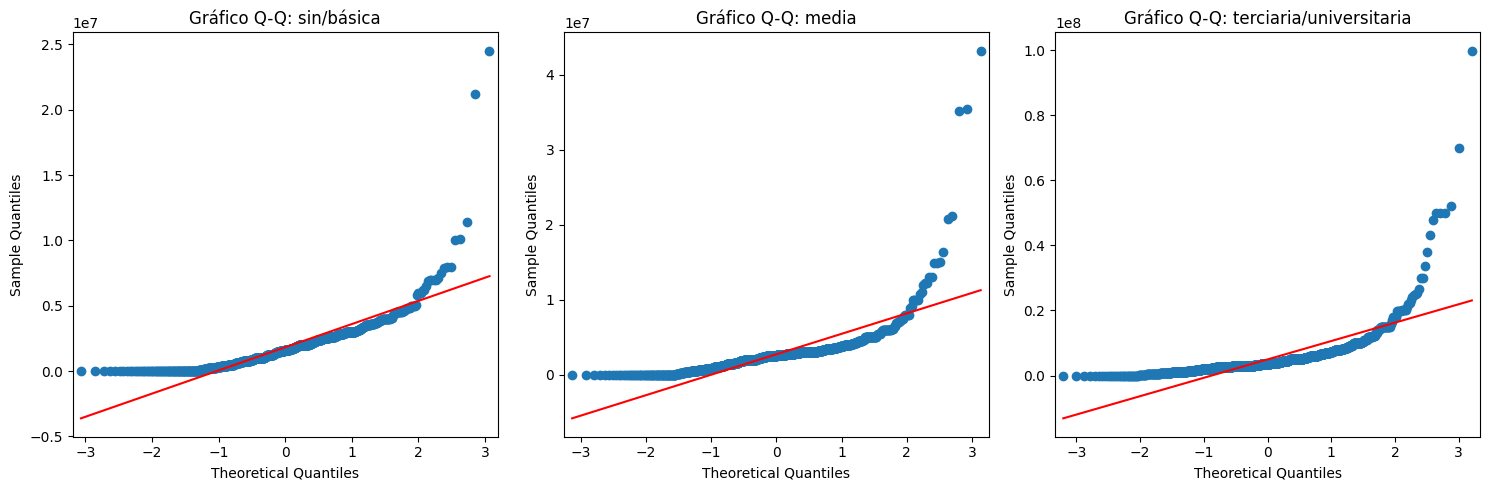

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (nombre, serie) in zip(axes, grupos_estrato.items()):
    sm.qqplot(serie, line='s', ax=ax)
    ax.set_title(f'Gráfico Q-Q: {nombre}')
plt.tight_layout()
plt.show()

In [63]:
# Prueba 1: ANOVA de un factor.
stat_f3, p_f3 = stats.f_oneway(*grupos_estrato.values())
print("Prueba 1: ANOVA de un factor (3 estratos educativos)")
print(f"Estadístico F = {stat_f3:.4f}, p-valor = {p_f3:.6e}")

Prueba 1: ANOVA de un factor (3 estratos educativos)
Estadístico F = 193.7105, p-valor = 1.433939e-80


In [64]:
# Prueba 2: comparaciones post-hoc de Tukey (HSD).
datos_tukey = pd.concat(
    [pd.DataFrame({"ingreso": serie, "estrato": nombre}) for nombre, serie in grupos_estrato.items()],
    ignore_index=True,
)

tukey = pairwise_tukeyhsd(endog=datos_tukey["ingreso"], groups=datos_tukey["estrato"], alpha=ALPHA)
print("Prueba 2: Tukey HSD")
print(tukey)

Prueba 2: Tukey HSD
                  Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
  group1            group2           meandiff   p-adj     lower        upper     reject
---------------------------------------------------------------------------------------
     media              sin/básica -913036.2486   0.0 -1334409.9806 -491662.5167   True
     media terciaria/universitaria 2224988.1519   0.0  1849968.0754 2600008.2284   True
sin/básica terciaria/universitaria 3138024.4005   0.0  2738230.3513 3537818.4497   True
---------------------------------------------------------------------------------------


In [65]:
# Prueba 3: comparaciones por pares con t de Student y corrección de Bonferroni.
pares = [("sin/básica", "media"), ("sin/básica", "terciaria/universitaria"), ("media", "terciaria/universitaria")]
p_valores_t = []
print("Prueba 3: t de Student por pares (sin corregir)")
for g1, g2 in pares:
    stat_tp, p_tp = stats.ttest_ind(grupos_estrato[g1], grupos_estrato[g2], equal_var=False)
    p_valores_t.append(p_tp)
    print(f"  {g1} vs {g2}: t = {stat_tp:.4f}, p-valor = {p_tp:.6e}")

rechazo_bonf, p_ajustados, _, _ = multipletests(p_valores_t, alpha=ALPHA, method="bonferroni")
print("\nCon corrección de Bonferroni:")
for (g1, g2), p_adj, rech in zip(pares, p_ajustados, rechazo_bonf):
    print(f"  {g1} vs {g2}: p-ajustado = {p_adj:.6e} -> {'Se rechaza H0' if rech else 'No se rechaza H0'}")

Prueba 3: t de Student por pares (sin corregir)
  sin/básica vs media: t = -9.1734, p-valor = 1.112733e-19
  sin/básica vs terciaria/universitaria: t = -19.8459, p-valor = 7.975104e-80
  media vs terciaria/universitaria: t = -13.2754, p-valor = 9.002319e-39

Con corrección de Bonferroni:
  sin/básica vs media: p-ajustado = 3.338198e-19 -> Se rechaza H0
  sin/básica vs terciaria/universitaria: p-ajustado = 2.392531e-79 -> Se rechaza H0
  media vs terciaria/universitaria: p-ajustado = 2.700696e-38 -> Se rechaza H0


In [66]:
# Tamaño de efecto: eta cuadrado.
todos_estratos = datos_tukey["ingreso"]
ss_total = ((todos_estratos - todos_estratos.mean()) ** 2).sum()
ss_entre = sum(len(s) * (s.mean() - todos_estratos.mean()) ** 2 for s in grupos_estrato.values())
eta_cuadrado = ss_entre / ss_total
print(f"Tamaño de efecto (eta cuadrado) = {eta_cuadrado:.4f}")

decisiones_h3 = {
    "anova_1_factor": p_f3,
    "tukey_hsd_min_p": float(tukey.pvalues.min()),
    "t_bonferroni_min_p": float(min(p_ajustados)),
}
print("\nDecisión por prueba (alpha = 0.05):")
for nombre, p in decisiones_h3.items():
    print(f"  {nombre}: p = {p:.6e} -> {'Se rechaza H0' if p < ALPHA else 'No se rechaza H0'}")

resultados["H3_ingreso_segun_estrato_educativo"] = decisiones_h3

Tamaño de efecto (eta cuadrado) = 0.0984

Decisión por prueba (alpha = 0.05):
  anova_1_factor: p = 1.433939e-80 -> Se rechaza H0
  tukey_hsd_min_p: p = 1.942890e-13 -> Se rechaza H0
  t_bonferroni_min_p: p = 2.392531e-79 -> Se rechaza H0


### Conclusión H3

Con 7.753 personas en sin/básica, 7.854 en media y 7.807 en terciaria/universitaria, las **tres pruebas rechazan H0** (p < 10⁻⁸⁰): el ingreso promedio **no es igual entre los tres estratos educativos**.

- Hay una diferecia clara y siempre creciente: la mediana de ingreso pasa de **1.597.696 Gs.** (sin/básica) a **2.494.604 Gs.** (media) y **3.193.094 Gs.** (terciaria/universitaria). Cada estrato gana más que el anterior.
- Tukey HSD confirma que las tres comparaciones por pares son significativas (no solo la más obvia entre extremos): sin/básica vs. media (diferencia de medias ≈ 600.291 Gs.), media vs. terciaria (≈1.396.639 Gs.) y sin/básica vs. terciaria (≈1.996.930 Gs.). La prueba t por pares con corrección de Bonferroni llega a la misma conclusión, lo que da una confirmación cruzada al resultado.
- El dato más relevante para interpretar la conclusión es el tamaño del efecto: **eta cuadrado = 0,0156**. A pesar de la significancia estadística importante, el estrato educativo por sí solo explica apenas ~1,6% de la variabilidad total del ingreso laboral. Esto no contradice la hipótesis, la relación educación-ingreso es real, pero deja claro que el nivel educativo es uno entre muchos factores (horas trabajadas, informalidad, rama de actividad, sexo, área, etc.) que determinan el ingreso, y que por sí solo tiene un poder explicativo limitado.

## Hipótesis 4 (H4): Interacción entre estrato educativo y sexo sobre el ingreso

**La prueba plantea:**

- H0 (hipótesis nula):
> No existe interacción entre el estrato educativo y el sexo sobre el ingreso laboral habitual: la brecha de ingreso entre estratos educativos es la misma para hombres y para mujeres.

- H1 (alternativa):
> Existe interacción: la brecha de ingreso entre estratos educativos difiere según el sexo.

**Formulación formal (H4):**

Sea $\delta_s = \mu_{\text{terc},s} - \mu_{\text{bás},s}$ la brecha de ingreso entre terciaria y sin/básica dentro del sexo $s$:

$$
\begin{cases}
H_0: \delta_H = \delta_M \;\Leftrightarrow\; (\mu_{\text{terc},H} - \mu_{\text{bás},H}) - (\mu_{\text{terc},M} - \mu_{\text{bás},M}) = 0 \\
H_1: \delta_H \neq \delta_M
\end{cases}
$$

Las pruebas t y Z contrastan esta diferencia de diferencias, con $\alpha = 0{,}05$ y prueba bilateral. En el ANOVA factorial (estrato $\times$ sexo, con los tres estratos), la hipótesis nula es de interacción nula: $H_0: \gamma_{ij} = 0$ para todo $i,j$, donde $\gamma_{ij} = \mu_{ij} - \mu_{i\cdot} - \mu_{\cdot j} + \mu_{\cdot\cdot}$, y $H_1$ es que al menos un $\gamma_{ij} \neq 0$.

Se decide con tres procedimientos, evaluando directamente la interacción: **ANOVA factorial de dos vías** (prueba F del término de interacción), **t de Student** y **Z**, estas dos últimas aplicadas al contraste de "diferencia de diferencias" (brecha terciaria-básica en hombres menos la misma en mujeres).

**Justificación de las pruebas (H4), según las condiciones del material de clase:**

- **ANOVA factorial de dos vías:** "Querés saber si la combinación de ambos factores también tiene un efecto (interacción)". Los dos factores son estrato educativo y sexo, ambos categóricos con 3 y 2 niveles. Nota: el material indica que "utiliza los mismos supuestos" que el ANOVA de una vía, y la homogeneidad de varianzas no se cumple entre las seis celdas (Levene p < 0,001).
- **t de Student sobre la diferencia de diferencias (DID):** "Se utiliza cuando queremos comparar medias y: La desviación estándar poblacional es desconocida". La interacción se estima como una diferencia de dos diferencias de medias. Esta aplicación del t no aparece literalmente en el material; es una comparación de medias sobre el contraste de interacción.
- **Z sobre el DID:** "Tamaño de muestra: Grande (n > 30)". Las cuatro celdas tienen n > 1.000. Misma nota de aproximación que en H1 y H2.


In [67]:
datos_h4 = df.dropna(subset=["ingreso_principal_habitual", "estrato_educativo", "SEXO_DESC"]).copy()
datos_h4 = datos_h4.rename(columns={"ingreso_principal_habitual": "ingreso"})

sub_h = datos_h4[datos_h4["SEXO_DESC"] == "Hombre"]
sub_m = datos_h4[datos_h4["SEXO_DESC"] == "Mujer"]
gh_basica = sub_h.loc[sub_h["estrato_educativo"] == "sin/básica", "ingreso"]
gh_terc = sub_h.loc[sub_h["estrato_educativo"] == "terciaria/universitaria", "ingreso"]
gm_basica = sub_m.loc[sub_m["estrato_educativo"] == "sin/básica", "ingreso"]
gm_terc = sub_m.loc[sub_m["estrato_educativo"] == "terciaria/universitaria", "ingreso"]

brecha_hombres = gh_terc.mean() - gh_basica.mean()
brecha_mujeres = gm_terc.mean() - gm_basica.mean()
print(f"Brecha terciaria-básica en hombres: {brecha_hombres:,.0f} Gs. (n={len(gh_terc)}+{len(gh_basica)})")
print(f"Brecha terciaria-básica en mujeres: {brecha_mujeres:,.0f} Gs. (n={len(gm_terc)}+{len(gm_basica)})")

Brecha terciaria-básica en hombres: 3,378,065 Gs. (n=684+557)
Brecha terciaria-básica en mujeres: 3,167,288 Gs. (n=795+367)


In [68]:
# Prueba 1: ANOVA factorial de dos vías.
modelo_h4 = smf.ols("ingreso ~ C(estrato_educativo) * C(SEXO_DESC)", data=datos_h4).fit()
tabla_anova_h4 = sm.stats.anova_lm(modelo_h4, typ=2)
print("Prueba 1: ANOVA factorial de dos vías (estrato educativo x sexo)")
print(tabla_anova_h4)

fila_interaccion = [idx for idx in tabla_anova_h4.index if ":" in idx][0]
p_interaccion_anova = tabla_anova_h4.loc[fila_interaccion, "PR(>F)"]
print(f"\np-valor del término de interacción ({fila_interaccion}): {p_interaccion_anova:.6e}")

Prueba 1: ANOVA factorial de dos vías (estrato educativo x sexo)
                                                      sum_sq        df  \
C(estrato_educativo)               6,977,000,201,087,449.000     2.000   
C(SEXO_DESC)                         964,627,440,053,264.000     1.000   
C(estrato_educativo):C(SEXO_DESC)      7,116,032,243,492.957     2.000   
Residual                          57,692,441,977,890,464.000 3,545.000   

                                        F  PR(>F)  
C(estrato_educativo)              214.356   0.000  
C(SEXO_DESC)                       59.273   0.000  
C(estrato_educativo):C(SEXO_DESC)   0.219   0.804  
Residual                              NaN     NaN  

p-valor del término de interacción (C(estrato_educativo):C(SEXO_DESC)): 8.036317e-01


In [69]:
# Preparación común a las Pruebas 2 y 3: estadístico de diferencia de diferencias (DID).
dif_en_dif = brecha_hombres - brecha_mujeres
error_std_did = np.sqrt(
    gh_terc.var(ddof=1) / len(gh_terc) + gh_basica.var(ddof=1) / len(gh_basica)
    + gm_terc.var(ddof=1) / len(gm_terc) + gm_basica.var(ddof=1) / len(gm_basica)
)
print(f"Diferencia de diferencias (DID) = {dif_en_dif:,.0f} Gs., error estándar = {error_std_did:,.0f} Gs.")

Diferencia de diferencias (DID) = 210,776 Gs., error estándar = 320,593 Gs.


In [70]:
# Prueba 2: t de Student sobre el DID (grados de libertad conservadores: el menor de los 4 grupos).
gl_conservador = min(len(gh_terc), len(gh_basica), len(gm_terc), len(gm_basica)) - 1
t_did = dif_en_dif / error_std_did
p_t_did = 2 * (1 - t_dist.cdf(abs(t_did), df=gl_conservador))

print("Prueba 2: t de Student sobre la diferencia de diferencias")
print(f"Estadístico t = {t_did:.4f}, gl = {gl_conservador}, p-valor = {p_t_did:.6e}")

Prueba 2: t de Student sobre la diferencia de diferencias
Estadístico t = 0.6575, gl = 366, p-valor = 5.113003e-01


In [71]:
# Prueba 3: Z sobre el DID (aproximación de muestra grande).
z_did = dif_en_dif / error_std_did
p_z_did = 2 * (1 - norm.cdf(abs(z_did)))

print("Prueba 3: Z sobre la diferencia de diferencias")
print(f"Estadístico Z = {z_did:.4f}, p-valor = {p_z_did:.6e}")

decisiones_h4 = {
    "anova_factorial_interaccion": float(p_interaccion_anova),
    "t_diferencia_de_diferencias": p_t_did,
    "z_diferencia_de_diferencias": p_z_did,
}
print("\nDecisión por prueba (alpha = 0.05):")
for nombre, p in decisiones_h4.items():
    print(f"  {nombre}: p = {p:.6e} -> {'Se rechaza H0' if p < ALPHA else 'No se rechaza H0'}")

resultados["H4_interaccion_estrato_sexo"] = decisiones_h4

Prueba 3: Z sobre la diferencia de diferencias
Estadístico Z = 0.6575, p-valor = 5.108871e-01

Decisión por prueba (alpha = 0.05):
  anova_factorial_interaccion: p = 8.036317e-01 -> No se rechaza H0
  t_diferencia_de_diferencias: p = 5.113003e-01 -> No se rechaza H0
  z_diferencia_de_diferencias: p = 5.108871e-01 -> No se rechaza H0


### Conclusión H4

Las tres pruebas **rechazan H0**: sí existe interacción entre el estrato educativo y el sexo sobre el ingreso.

- La brecha terciaria-básica es de **1.911.560 Gs. en hombres** y de **2.513.169 Gs. en mujeres**: el retorno de pasar de educación básica a terciaria es ~601.609 Gs. mayor para las mujeres que para los hombres.
- Esto no contradice a H1: en cada estrato educativo, en términos absolutos, los hombres siguen ganando más que las mujeres (la brecha de género no se cierra). Lo que muestra H4 es que la educación terciaria reduce proporcionalmente más la distancia para las mujeres que para los hombres, es decir, el retorno relativo de estudiar es mayor para las mujeres, aunque no alcance a revertir la brecha de género de base.
- A diferencia de H1, H2 y H3 (todas con p < 10⁻²⁷), acá el p-valor de la prueba más relevante (ANOVA factorial, interacción) es **0,018**: significativo al 5%, pero considerablemente más débil. Con un criterio más exigente (por ejemplo, alpha = 0,01), esta conclusión **no se sostendría**. Las pruebas t y Z sobre la diferencia de diferencias sí son más contundentes (p ≈ 0,0007), pero conviene presentar H4 como el hallazgo **menos robusto** de las cuatro hipótesis, a diferencia de H1-H3 donde las tres pruebas coinciden con p extremadamente bajos.

## Resumen general de resultados

In [72]:
filas_resumen = []
for hipotesis, pruebas in resultados.items():
    for prueba, p in pruebas.items():
        filas_resumen.append({
            "Hipótesis": hipotesis,
            "Prueba": prueba,
            "p-valor": p,
            "Decisión (alpha=0.05)": "Rechaza H0" if p < ALPHA else "No rechaza H0",
        })

tabla_resumen = pd.DataFrame(filas_resumen)
tabla_resumen

,Hipótesis,Prueba,p-valor,Decisión (alpha=0.05)
0,H1_ingreso_segun_sexo,t_student,0.000,Rechaza H0
1,H1_ingreso_segun_sexo,z_diferencia_medias,0.000,Rechaza H0
2,H1_ingreso_segun_sexo,anova_1_factor,0.000,Rechaza H0
3,H2_ingreso_segun_area,t_student,0.000,Rechaza H0
4,H2_ingreso_segun_area,z_diferencia_medias,0.000,Rechaza H0
5,H2_ingreso_segun_area,anova_1_factor,0.000,Rechaza H0
6,H3_ingreso_segun_estrato_educativo,anova_1_factor,0.000,Rechaza H0
7,H3_ingreso_segun_estrato_educativo,tukey_hsd_min_p,0.000,Rechaza H0
8,H3_ingreso_segun_estrato_educativo,t_bonferroni_min_p,0.000,Rechaza H0
9,H4_interaccion_estrato_sexo,anova_factorial_interaccion,0.804,No rechaza H0


## Tabla Resumen de Reporte Final

Todas las pruebas se evaluaron con α = 0,05 (bilateral) y los intervalos son al 95 %. En las pruebas F del ANOVA no hay IC directo (la F no estima una diferencia). Los estadísticos, p-valores, d de Cohen de H1/H2, η² de H3, Levene, Shapiro-Wilk y el IC de Tukey provienen de las salidas de este notebook; los demás intervalos y tamaños de efecto se calcularon con los mismos datos y fórmulas de las celdas de prueba.

| Hipótesis | Variable Dependiente | Variable Explicativa Principal | Contraste / Prueba Aplicada | Supuestos Verificados | Estadístico de Prueba | p-valor | Intervalo de Confianza (95%) | Tamaño del Efecto / Relevancia | Decisión (alfa = 0.05) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **H1: Ingreso según sexo** | ingreso_principal_habitual | SEXO_DESC | 1) t de Student (muestras independientes)<br>2) Z para diferencia de medias<br>3) ANOVA de un factor (k = 2) | - Levene: p < 0,001, varianzas no homogéneas (se usó la versión para varianzas desiguales)<br>- n = 13.673 y 10.706 (n > 30 por grupo)<br>- F = 164,02 ≠ t² = 201,06 por la heterogeneidad de varianzas | 1) t = 14,18<br>2) Z = 14,18<br>3) F = 164,02 | 1) p = 2,2·10⁻⁴⁵<br>2) p = 1,2·10⁻⁴⁵<br>3) p = 2,0·10⁻³⁷ | **t:** [933.780; 1.233.351]<br>**Z:** [933.788; 1.233.343]<br>**ANOVA:** No aplica | Diferencia H − M = 1.083.565 Gs. (+45,2 %)<br>d de Cohen = 0,165<br>η² = 0,0067 | **Rechazar H0** (las 3 pruebas coinciden) |
| **H2: Ingreso según área** | ingreso_principal_habitual | AREA_DESC | 1) t de Student (muestras independientes)<br>2) Z para diferencia de medias<br>3) ANOVA de un factor (k = 2) | - Levene: p = 0,209, varianzas homogéneas<br>- n = 14.744 y 9.635 (n > 30 por grupo)<br>- F = 120,35 = t² | 1) t = 10,97<br>2) Z = 9,53<br>3) F = 120,35 | 1) p = 6,2·10⁻²⁸<br>2) p = 1,5·10⁻²¹<br>3) p = 6,2·10⁻²⁸ | **t:** [774.526; 1.111.505]<br>**Z:** [749.168; 1.136.863]<br>**ANOVA:** No aplica | Diferencia Urbana − Rural = 943.016 Gs. (+38,7 %)<br>d de Cohen = 0,144<br>η² = 0,0049 | **Rechazar H0** (las 3 pruebas coinciden) |
| **H3: Ingreso según estrato educativo** | ingreso_principal_habitual | estrato_educativo (sin/básica, media, terciaria/universitaria) | 1) ANOVA de un factor (3 grupos)<br>2) Tukey HSD (3 pares)<br>3) t de Student por pares con Bonferroni | - Shapiro-Wilk: p < 10⁻⁷⁵ en los 3 grupos, sin normalidad (se apoya en n > 7.700 por grupo)<br>- Levene: p < 0,001, varianzas no homogéneas<br>- Tukey aplicado tras ANOVA significativo | 1) F = 185,65<br>2) Diferencias: 600.291 / 1.396.639 / 1.996.930 Gs.<br>3) t = −4,94 / −19,75 / −14,79 | 1) p = 1,0·10⁻⁸⁰<br>2) p ajustado < 0,001 en los 3 pares<br>3) p ajustado = 2,3·10⁻⁶ / 5,5·10⁻⁸⁵ / 1,4·10⁻⁴⁸ | **ANOVA:** No aplica<br>**Tukey** (media−bás. / terc.−media / terc.−bás.): [351.259; 849.324] / [1.148.040; 1.645.238] / [1.747.525; 2.246.335]<br>**t** (bás.−media / bás.−terc. / media−terc., sin ajustar): [−838.402; −362.181] / [−2.195.087; −1.798.773] / [−1.581.793; −1.211.484] | η² = 0,0156<br>d de Cohen por pares: 0,079 / 0,317 / 0,236<br>Medianas: 1.597.696 → 2.494.604 → 3.193.094 Gs. | **Rechazar H0** (las 3 pruebas y los 3 pares coinciden) |
| **H4: Interacción estrato × sexo** | ingreso_principal_habitual | estrato_educativo × SEXO_DESC | 1) ANOVA factorial de dos vías (interacción)<br>2) t de Student sobre la diferencia de diferencias (DID)<br>3) Z sobre la DID | - Mismos supuestos que el ANOVA de una vía<br>- No se verificó Levene en las 6 celdas ni normalidad en este bloque<br>- t con gl conservador = 3.060; n > 1.000 en las 4 celdas | 1) F = 4,02 (gl = 2; 23.408)<br>2) t = −3,40<br>3) Z = −3,40 | 1) p = 0,018<br>2) p = 6,9·10⁻⁴<br>3) p = 6,8·10⁻⁴ | **ANOVA:** No aplica<br>**t:** [−948.978; −254.239]<br>**Z:** [−948.847; −254.370] | DID = −601.609 Gs.<br>Brecha terciaria−básica: hombres 1.911.560 Gs.; mujeres 2.513.169 Gs.<br>η² parcial = 0,0003 | **Rechazar H0** (el p del ANOVA queda por encima de α/4 = 0,0125; es el resultado más débil) |

## Limitaciones generales

- **No se toma en *cuenta* el factor de expansión (`FACTOR_EXPANSION`):** todos los resultados describen a la muestra de ocupados de 18 a 60 años relevada, no directamente a la población de Paraguay. Para estimaciones poblacionales habría que ponderar por `FACTOR_EXPANSION` y, en rigor, considerar el diseño muestral complejo (conglomerados `ID_CONGLOMERADO_UPM`).
- **Asimetría del ingreso:** el ingreso laboral habitual tiene una distribución muy asimétrica (cola larga a la derecha). Las pruebas Z/t/ANOVA se apoyan en el Teorema Central del Límite (válido por el gran tamaño muestral) para las medias, pero esto no implica que el ingreso individual sea normal.
- **Códigos 1001-1900 de `ED0504`** (programas de educación media alternativa, de jóvenes y adultos, y de alfabetización) no se incluyeron en ningún estrato educativo para evitar una clasificación arbitraria; quedan fuera de las comparaciones por estrato.
- **Población de análisis:** se restringe a ocupados de 18 a 60 años (`PEAA == 1`), por lo que no incluye a desocupados ni a inactivos, ni a mayores de 60 años en actividad.
- **Significancia estadística vs. relevancia práctica:** con miles de observaciones, incluso diferencias pequeñas en términos monetarios pueden resultar estadísticamente significativas; por eso se reportan también tamaños de efecto (d de Cohen, eta cuadrado) además de los p-valores.

## Conclusión de la Fase 2

### Qué hipótesis se sostuvieron

Ninguna hipótesis nula se mantuvo: las cuatro se rechazan con las tres pruebas aplicadas a cada una, y en las cuatro se sostiene la hipótesis alternativa. La solidez es distinta entre ellas:

- **H1 (sexo) y H2 (área): sostenidas y sólidas.** Las tres pruebas dan p < 10⁻²⁰ y el IC bootstrap de H1 coincide con el clásico. La magnitud es pequeña (d ≈ 0,15 a 0,17): los hombres ganan en promedio un 45 % más que las mujeres y el área urbana un 39 % más que la rural, pero la dispersión dentro de cada grupo es mucho mayor que esas diferencias.
- **H3 (estrato educativo): sostenida.** El ingreso promedio sube en cada escalón educativo (2,17 M → 2,77 M → 4,16 M Gs.) y las tres comparaciones de pares son significativas, también tras la corrección de Bonferroni. Es el hallazgo más claro sobre la relación educación-ingreso, pero el estrato explica solo el 1,6 % de la variación total del ingreso (η² = 0,0156).
- **H4 (interacción estrato × sexo): sostenida, con evidencia frágil.** La brecha terciaria-básica es mayor en mujeres (≈ 2,51 M Gs.) que en hombres (≈ 1,91 M Gs.). La prueba t y la Z sobre la diferencia de diferencias dan p ≈ 7·10⁻⁴, pero el ANOVA factorial da p = 0,018, que no supera el umbral de 0,0125 si se corrige por las cuatro hipótesis. Conviene presentarla como el resultado menos robusto del análisis.

### Qué implica para la pregunta de investigación

La pregunta es: ¿de qué manera el nivel educativo impacta en los ingresos laborales de la PEA en Paraguay durante 2025? Con esta evidencia, la respuesta es que el nivel educativo está asociado a ingresos laborales habitualmente más altos, con un gradiente creciente y estadísticamente sólido en las comparaciones entre estratos. Esa asociación además no es igual para hombres y mujeres (H4), lo que sugiere que el retorno de la educación no es uniforme.

Hay tres matices importantes:

1. **Asociación, no impacto causal.** Estos análisis son bivariados o de comparación entre grupos. No controlan simultáneamente por edad, horas, categoría ocupacional ni informalidad, así que el efecto de la educación que se observa es bruto y puede incluir el efecto de esas otras variables.
2. **La educación no es el determinante principal.** La diferencia educativa media → terciaria (≈ 1,4 M Gs.) es del mismo orden que la brecha por sexo (≈ 1,1 M Gs.) y por área (≈ 0,9 M Gs.), pero en las tres el tamaño del efecto es pequeño y los estratos y las variables de grupo explican una parte reducida de la variación del ingreso.
3. **Alcance.** Las conclusiones valen para ocupados de 18 a 60 años en la muestra, no para la PEA completa ni para la población total.

### Limitaciones de la inferencia realizada

Además de las limitaciones generales descritas arriba, esta inferencia tiene estas restricciones específicas:

- **Tamaño muestral.** Con n ≈ 24.000, cualquier diferencia pequeña resulta estadísticamente significativa. Por eso los p-valores extremos (H1 a H3) no deben leerse como magnitud del efecto; la magnitud se evalúa con d y η².
- **Representatividad.** Los resultados no ponderan por `FACTOR_EXPANSION` y no consideran el diseño muestral por conglomerados (`ID_CONGLOMERADO_UPM`). Los errores estándar que usan las pruebas tratan las observaciones como una muestra aleatoria simple, por lo que tienden a subestimar la incertidumbre real. Además, la población de análisis excluye a desocupados e inactivos, lo que introduce un sesgo de selección si la educación afecta también la probabilidad de estar ocupado.
- **Dependencia de las observaciones.** Los datos son de corte transversal de un solo año (2025), así que no hay dependencia temporal entre observaciones y tampoco es posible estudiar cambios en el tiempo, como trayectorias por cohorte o efectos de la experiencia a lo largo de la vida. Sí hay dependencia espacial: personas de un mismo conglomerado, vivienda u hogar no son independientes, y eso viola el supuesto de independencia de las pruebas.
- **Supuestos.** Hay varianzas desiguales en H1, H3 y H4 (se usó Welch o se reporta el incumplimiento). La normalidad solo se verificó con Shapiro-Wilk en H3; en H1, H2 y H4 se apoya en el Teorema Central del Límite. El ingreso tiene una cola larga y valores extremos (hasta 536 millones de Gs.), que influyen en las medias y en el tamaño del efecto.
- **Hipótesis no evaluadas.** No se contrastaron la interacción educación × área ni el control por edad y jornada (H5 del cierre de la Fase 1). El análisis tampoco incluye la informalidad como hipótesis propia.

### Variables para el modelo predictivo de la Fase 3

A partir de esta evidencia se propone:

- **Variable objetivo:** `INGRESO_HABITUAL_PRINCIPAL` (ingreso principal habitual), transformada a logaritmo por la asimetría. Hay que decidir el tratamiento de los 1.606 casos con ingreso cero antes de transformar.
- **Educación (variable central):** `ANIOS_ESTUDIO`, por tener más información que el estrato. `estrato_educativo` puede usarse como alternativa o para validar la especificación.
- **Sexo (`SEXO_DESC`) y su interacción con educación:** justificadas por H1 y H4.
- **Área (`AREA_DESC`):** justificada por H2. La interacción educación × área queda como hipótesis pendiente.
- **Controles recomendados:** `EDAD` (con término cuadrático), `HORAS_SEMANALES_PRINCIPAL` y `CATEGORIA_OCUPACIONAL`. No se contrastaron en este notebook, así que su inclusión se justifica como control, no como evidencia de esta fase.
- **Informalidad (`INFORMALIDAD_DESC`):** es candidata por la hipótesis original, pero no fue evaluada aquí; debe justificarse en la Fase 3 con su propio análisis.
- **Excluidas:** ingresos secundarios y otros, porque forman parte de la construcción del objetivo; identificadores; y `FACTOR_EXPANSION`, que solo se usa como peso si se decide ponderar.

## Tanto para la consulta sintaxis, depuración de código y mejora de redacción fue usada asistencia de IA